## 1. EM Algorithm là gì?

Expectation-Maximization (EM) là một thuật toán tối ưu lặp dùng để **ước lượng tham số** cho các mô hình xác suất, đặc biệt hữu ích khi:
- dữ liệu bị thiếu,
- dữ liệu có nhiễu,
- hoặc tồn tại các biến ẩn (`latent variables`) mà ta không quan sát trực tiếp.

Thuật toán hoạt động theo 2 bước lặp đi lặp lại:
- `E-step` (Expectation Step): ước lượng xác suất mỗi điểm dữ liệu thuộc về từng thành phần ẩn.
- `M-step` (Maximization Step): cập nhật lại tham số của mô hình sao cho giải thích dữ liệu tốt hơn.

Quá trình này lặp lại cho đến khi mô hình hội tụ, tức là tham số thay đổi rất ít hoặc `log-likelihood` gần như không tăng thêm nữa.

## 2. Một vài khái niệm quan trọng

- `Latent variables`: biến ẩn, không quan sát trực tiếp nhưng ảnh hưởng đến dữ liệu.
- `Likelihood`: xác suất sinh ra dữ liệu quan sát được dưới một bộ tham số nhất định.
- `Log-likelihood`: log của likelihood, giúp tính toán ổn định và dễ tối ưu hơn.
- `Posterior probability`: xác suất hậu nghiệm, trong EM thường là xác suất một điểm thuộc về một thành phần nào đó.
- `Convergence`: điều kiện dừng khi mô hình đã ổn định.

Trong ví dụ của bài này, ta giả sử dữ liệu được sinh ra từ **hai phân phối Gaussian trộn lẫn nhau**. Điều chưa biết là:
- trung bình của mỗi Gaussian,
- độ lệch chuẩn của mỗi Gaussian,
- tỉ lệ đóng góp của mỗi Gaussian vào toàn bộ dữ liệu.

## 3. Chuẩn bị thư viện

Notebook dùng `numpy`, `seaborn`, `matplotlib` và `scipy` giống bài gốc.

Nếu máy chưa có các thư viện này, có thể cài bằng lệnh:
`pip install numpy seaborn matplotlib scipy notebook`

In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde

np.random.seed(42)


## 4. Tạo dữ liệu từ hai Gaussian

Ta tạo hai nhóm dữ liệu:
- nhóm thứ nhất có trung bình gần `2` và độ lệch chuẩn `1`,
- nhóm thứ hai có trung bình gần `-1` và độ lệch chuẩn `0.8`.

Sau đó gộp chúng lại thành một tập dữ liệu duy nhất. Đây là tình huống điển hình mà ta biết dữ liệu là hỗn hợp của nhiều phân phối, nhưng không biết chính xác mỗi điểm đến từ thành phần nào.

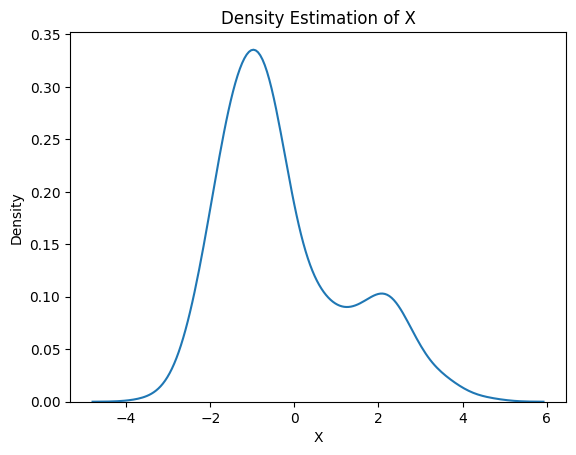

In [2]:
mu1, sigma1 = 2, 1
mu2, sigma2 = -1, 0.8

X1 = np.random.normal(mu1, sigma1, size=200)
X2 = np.random.normal(mu2, sigma2, size=600)
X = np.concatenate([X1, X2])

sns.kdeplot(X)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Density Estimation of X')
plt.show()


### Giải thích

Biểu đồ mật độ cho thấy dữ liệu không phải chỉ có một đỉnh đơn giản. Nó có xu hướng là hỗn hợp của hai nhóm. EM sẽ cố gắng học ra hai thành phần Gaussian ẩn này.

## 5. Khởi tạo tham số ban đầu

Ở bước này, ta đặt giá trị khởi tạo cho:
- `mu1_hat`, `mu2_hat`: trung bình ước lượng,
- `sigma1_hat`, `sigma2_hat`: độ lệch chuẩn ước lượng,
- `pi1_hat`, `pi2_hat`: tỉ lệ trộn của hai thành phần.

Trong bài gốc, các giá trị khởi tạo được lấy trực tiếp từ `X1` và `X2` để minh họa đơn giản. Trong thực tế, khởi tạo có thể ngẫu nhiên hoặc lấy từ một thủ thuật như KMeans.

In [3]:
mu1_hat, sigma1_hat = np.mean(X1), np.std(X1)
mu2_hat, sigma2_hat = np.mean(X2), np.std(X2)
pi1_hat, pi2_hat = len(X1) / len(X), len(X2) / len(X)

print('Khoi tao ban dau:')
print(f'mu1_hat = {mu1_hat:.4f}, sigma1_hat = {sigma1_hat:.4f}, pi1_hat = {pi1_hat:.4f}')
print(f'mu2_hat = {mu2_hat:.4f}, sigma2_hat = {sigma2_hat:.4f}, pi2_hat = {pi2_hat:.4f}')


Khoi tao ban dau:
mu1_hat = 1.9592, sigma1_hat = 0.9287, pi1_hat = 0.2500
mu2_hat = -0.9976, sigma2_hat = 0.8002, pi2_hat = 0.7500


## 6. Chạy thuật toán EM

Ta lặp nhiều epoch. Mỗi epoch gồm hai phần:

`E-step`:
- tính mật độ xác suất của từng điểm dưới mỗi Gaussian,
- nhân với tỉ lệ trộn tương ứng,
- chuẩn hóa để thu được `gamma1`, `gamma2`, tức là mức độ "chịu trách nhiệm" của từng thành phần đối với mỗi điểm.

`M-step`:
- cập nhật lại trung bình có trọng số,
- cập nhật lại độ lệch chuẩn có trọng số,
- cập nhật lại tỉ lệ trộn.

Sau mỗi vòng lặp, ta lưu `log-likelihood` để xem mô hình có cải thiện hay không.

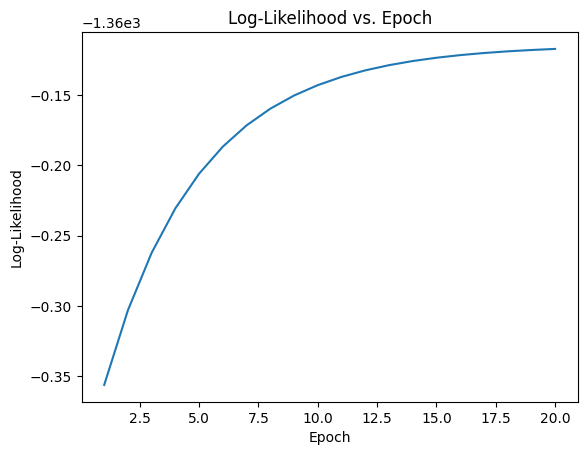

In [4]:
num_epochs = 20
log_likelihoods = []

for epoch in range(num_epochs):
    gamma1 = pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
    gamma2 = pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)
    total = gamma1 + gamma2

    gamma1 /= total
    gamma2 /= total

    mu1_hat = np.sum(gamma1 * X) / np.sum(gamma1)
    mu2_hat = np.sum(gamma2 * X) / np.sum(gamma2)

    sigma1_hat = np.sqrt(np.sum(gamma1 * (X - mu1_hat) ** 2) / np.sum(gamma1))
    sigma2_hat = np.sqrt(np.sum(gamma2 * (X - mu2_hat) ** 2) / np.sum(gamma2))

    pi1_hat = np.mean(gamma1)
    pi2_hat = np.mean(gamma2)

    log_likelihood = np.sum(
        np.log(
            pi1_hat * norm.pdf(X, mu1_hat, sigma1_hat)
            + pi2_hat * norm.pdf(X, mu2_hat, sigma2_hat)
        )
    )
    log_likelihoods.append(log_likelihood)

plt.plot(range(1, num_epochs + 1), log_likelihoods)
plt.xlabel('Epoch')
plt.ylabel('Log-Likelihood')
plt.title('Log-Likelihood vs. Epoch')
plt.show()


### Giải thích kết quả

Nếu thuật toán hoạt động đúng, `log-likelihood` thường sẽ tăng dần theo số vòng lặp. Điều này cho thấy mô hình đang tìm được bộ tham số giải thích dữ liệu ngày càng tốt hơn.

Ý nghĩa của `gamma`:
- nếu `gamma1` của một điểm cao, điểm đó có xu hướng thuộc Gaussian thứ nhất,
- nếu `gamma2` cao, điểm đó có xu hướng thuộc Gaussian thứ hai,
- khác với KMeans, EM không gán cứng tuyệt đối mà gán theo xác suất.

## 7. Xem tham số sau khi học

Sau khi EM hội tụ tương đối, ta in ra các tham số cuối cùng để xem mô hình đã ước lượng được gì từ dữ liệu.

In [5]:
print('Tham so sau khi hoc:')
print(f'mu1_hat = {mu1_hat:.4f}, sigma1_hat = {sigma1_hat:.4f}, pi1_hat = {pi1_hat:.4f}')
print(f'mu2_hat = {mu2_hat:.4f}, sigma2_hat = {sigma2_hat:.4f}, pi2_hat = {pi2_hat:.4f}')


Tham so sau khi hoc:
mu1_hat = 1.8847, sigma1_hat = 0.9804, pi1_hat = 0.2626
mu2_hat = -1.0215, sigma2_hat = 0.7788, pi2_hat = 0.7374


## 8. Trực quan hóa mật độ cuối cùng

Ta so sánh:
- `Kernel Density Estimation` (đường xanh): ước lượng mật độ trơn từ dữ liệu,
- `Mixture Density` (đường đỏ): mật độ do mô hình Gaussian mixture sau khi EM học được.

Nếu hai đường khá gần nhau, nghĩa là mô hình EM đang mô tả phân phối dữ liệu tương đối tốt.

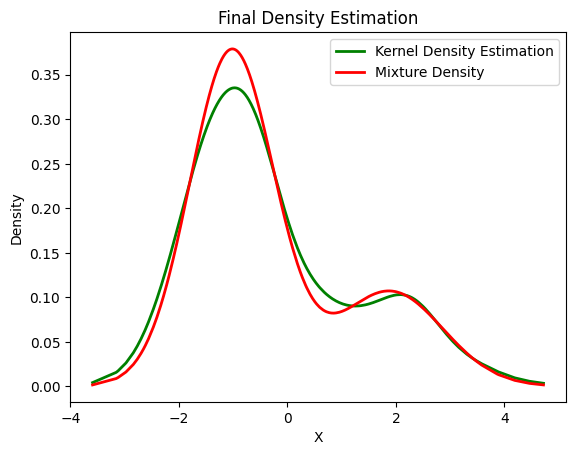

In [6]:
X_sorted = np.sort(X)
density_estimation = (
    pi1_hat * norm.pdf(X_sorted, mu1_hat, sigma1_hat)
    + pi2_hat * norm.pdf(X_sorted, mu2_hat, sigma2_hat)
)

plt.plot(X_sorted, gaussian_kde(X_sorted)(X_sorted), color='green', linewidth=2)
plt.plot(X_sorted, density_estimation, color='red', linewidth=2)
plt.xlabel('X')
plt.ylabel('Density')
plt.title('Final Density Estimation')
plt.legend(['Kernel Density Estimation', 'Mixture Density'])
plt.show()


## 9. Ưu điểm và hạn chế của EM

Ưu điểm:
- cải thiện `log-likelihood` theo hướng đơn điệu qua các vòng lặp,
- xử lý tốt bài toán có biến ẩn hoặc dữ liệu thiếu,
- dùng được cho nhiều mô hình xác suất khác nhau.

Hạn chế:
- có thể hội tụ chậm,
- nhạy với khởi tạo ban đầu,
- không đảm bảo tìm được nghiệm tối ưu toàn cục,
- chi phí tính toán tăng nếu dữ liệu lớn hoặc mô hình phức tạp.